# 01. Deep Agent

`uv add deepagents`

In [14]:
from dotenv import load_dotenv

load_dotenv()

True

In [15]:
from deepagents import create_deep_agent


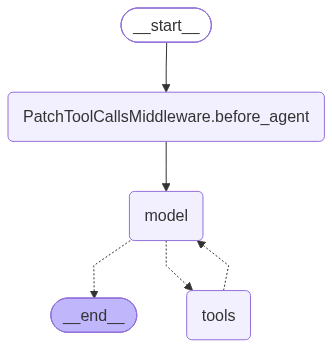

In [ ]:
from deepagents import create_deep_agent
from langchain_tavily import TavilySearch


SYSTEM_PROMPT = """You are an expert researcher. Your job is to conduct thorough research and then write a polished report.
Answer in KOREAN

You have access to an internet search tool as your primary means of gathering information.

## `internet_search`

Use this to run an internet search for a given query. You can specify the max number of results to return, the topic, and whether raw content should be included.
"""

# 모델이 자체적으로 인터넷 검색을 지원 할 경우에는, 아래처럼 tool로 작성 가능
# OpenAI 빌트인 검색
internet_search = {'type': 'web_search'}

tavily = TavilySearch()

agent = create_deep_agent(
    model='openai:gpt-5.4-mini',
    tools=[tavily],
    system_prompt=SYSTEM_PROMPT
)

agent

In [17]:
result = agent.invoke({
  'messages':[
    {'role':'user', 'content':'Langchain,Langgraph, DeepAgent 가 뭔지 설명해줘'}
  ]
})

## 02. Deep Research Agent
### Agent
- Prompt
    - Research 지침
    - SubAgent 위임 지침
- Tools
    - Tavily Search
    - Think
- SubAgent

In [18]:
from dotenv import load_dotenv
load_dotenv()

True

### Tools
`uv add markdownify`

In [ ]:
# Tool
"""Research Tools.

This module provides search and content processing utilities for the research agent,
using Tavily for URL discovery and fetching full webpage content.
"""

import httpx # Requests같은느낌 비동기요청을 할수있다는게 다름 
from langchain_core.tools import InjectedToolArg, tool
from markdownify import markdownify
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

tavily_client = TavilyClient()

# 단순 함수 (아래에서 tool 에서 사용)
def fetch_webpage_content(url: str, timeout: float = 10.0) -> str:
    """Fetch and convert webpage content to markdown.

    Args:
        url: URL to fetch
        timeout: Request timeout in seconds

    Returns:
        Webpage content as markdown
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36" #매크로 봇인지 걸러내지는거 막으려고 구라치는거
    }

    try:
        response = httpx.get(url, headers=headers, timeout=timeout)
        response.raise_for_status()
        return markdownify(response.text)
    except Exception as e:
        return f"Error fetching content from {url}: {str(e)}"


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[
        Literal["general", "news", "finance"], InjectedToolArg
    ] = "general",
) -> str:
    """Search the web for information on a given query.

    Uses Tavily to discover relevant URLs, then fetches and returns full webpage content as markdown.

    Args:
        query: Search query to execute
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Formatted search results with full webpage content
    """
    # Use Tavily to discover URLs
    search_results = tavily_client.search(
        query,
        max_results=max_results,
        topic=topic,
    )

    # Fetch full content for each URL
    result_texts = []
    for result in search_results.get("results", []):
        url = result["url"]
        title = result["title"]

        # Fetch webpage content
        content = fetch_webpage_content(url)

        result_text = f"""## {title}
**URL:** {url}

{content}

---
"""
        result_texts.append(result_text)

    # Format final response
    response = f"""🔍 Found {len(result_texts)} result(s) for '{query}':

{chr(10).join(result_texts)}"""

    return response

# 자기성찰 툴 AI가 행동하기 전에 반드시 이툴을 쓰게 한다음 반성문을 작성하게 하면 이툴을 호출할 때 마다 반성문을 쓰고 그내용을 그대로 반환해서 'messages'에 기록하게됨 -> 사실상 이 tool의 description이 본체이다!
@tool(parse_docstring=True) 
def think_tool(reflection: str) -> str:  #스스로 잠깐 멈춘다음 자신을 돌아보게 하는 도구 무지성 검색 방지, 리서치 품질 향상의 기능을 가짐 -> 'messages'에 tool에서 호출된 자기성찰 내용(반성문)이 들어가서 다음단계 체계적으로 계획가능
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?

    Reflection should address: 
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"


In [20]:
"""Prompt templates and tool descriptions for the research deepagent."""

RESEARCH_WORKFLOW_INSTRUCTIONS = """# Research Workflow

Follow this workflow for all research requests:

1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks
2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`
3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for research, never conduct research yourself
4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number across all findings)
5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines below)
6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and structure

## Research Planning Guidelines
- Batch similar research tasks into a single TODO to minimize overhead
- For simple fact-finding questions, use 1 sub-agent
- For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents
- Each sub-agent should research one specific aspect and return findings

## Report Writing Guidelines

When writing the final report to `/final_report.md`, follow these structure patterns:

**For comparisons:**
1. Introduction
2. Overview of topic A
3. Overview of topic B
4. Detailed comparison
5. Conclusion

**For lists/rankings:**
Simply list items with details - no introduction needed:
1. Item 1 with explanation
2. Item 2 with explanation
3. Item 3 with explanation

**For summaries/overviews:**
1. Overview of topic
2. Key concept 1
3. Key concept 2
4. Key concept 3
5. Conclusion

**General guidelines:**
- Use clear section headings (## for sections, ### for subsections)
- Write in paragraph form by default - be text-heavy, not just bullet points
- Do NOT use self-referential language ("I found...", "I researched...")
- Write as a professional report without meta-commentary
- Each section should be comprehensive and detailed
- Use bullet points only when listing is more appropriate than prose

**Citation format:**
- Cite sources inline using [1], [2], [3] format
- Assign each unique URL a single citation number across ALL sub-agent findings
- End report with ### Sources section listing each numbered source
- Number sources sequentially without gaps (1,2,3,4...)
- Format: [1] Source Title: URL (each on separate line for proper list rendering)
- Example:

  Some important finding [1]. Another key insight [2].

  ### Sources
  [1] AI Research Paper: https://example.com/paper
  [2] Industry Analysis: https://example.com/analysis
"""

RESEARCHER_INSTRUCTIONS = """You are a research assistant conducting research on the user's input topic. For context, today's date is {date}.

<Task>
Your job is to use tools to gather information about the user's input topic.
You can use any of the research tools provided to you to find resources that can help answer the research question.
You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.
</Task>

<Available Research Tools>
You have access to two specific research tools:
1. **tavily_search**: For conducting web searches to gather information
2. **think_tool**: For reflection and strategic planning during research
**CRITICAL: Use think_tool after each search to reflect on results and plan next steps**
</Available Research Tools>

<Instructions>
Think like a human researcher with limited time. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Start with broader searches** - Use broad, comprehensive queries first
3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?
4. **Execute narrower searches as you gather information** - Fill in the gaps
5. **Stop when you can answer confidently** - Don't keep searching for perfection
</Instructions>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 2-3 search tool calls maximum
- **Complex queries**: Use up to 5 search tool calls maximum
- **Always stop**: After 5 search tool calls if you cannot find the right sources

**Stop Immediately When**:
- You can answer the user's question comprehensively
- You have 3+ relevant examples/sources for the question
- Your last 2 searches returned similar information
</Hard Limits>

<Show Your Thinking>
After each search tool call, use think_tool to analyze the results:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?
</Show Your Thinking>

<Final Response Format>
When providing your findings back to the orchestrator:

1. **Structure your response**: Organize findings with clear headings and detailed explanations
2. **Cite sources inline**: Use [1], [2], [3] format when referencing information from your searches
3. **Include Sources section**: End with ### Sources listing each numbered source with title and URL

Example:
```
## Key Findings

Context engineering is a critical technique for AI agents [1]. Studies show that proper context management can improve performance by 40% [2].

### Sources
[1] Context Engineering Guide: https://example.com/context-guide
[2] AI Performance Study: https://example.com/study
```

The orchestrator will consolidate citations from all sub-agents into the final report.
</Final Response Format>
"""

TASK_DESCRIPTION_PREFIX = """Delegate a task to a specialized sub-agent with isolated context. Available agents for delegation are:
{other_agents}
"""

SUBAGENT_DELEGATION_INSTRUCTIONS = """# Sub-Agent Research Coordination

Your role is to coordinate research by delegating tasks from your TODO list to specialized research sub-agents.

## Delegation Strategy

**DEFAULT: Start with 1 sub-agent** for most queries:
- "What is quantum computing?" → 1 sub-agent (general overview)
- "List the top 10 coffee shops in San Francisco" → 1 sub-agent
- "Summarize the history of the internet" → 1 sub-agent
- "Research context engineering for AI agents" → 1 sub-agent (covers all aspects)

**ONLY parallelize when the query EXPLICITLY requires comparison or has clearly independent aspects:**

**Explicit comparisons** → 1 sub-agent per element:
- "Compare OpenAI vs Anthropic vs DeepMind AI safety approaches" → 3 parallel sub-agents
- "Compare Python vs JavaScript for web development" → 2 parallel sub-agents

**Clearly separated aspects** → 1 sub-agent per aspect (use sparingly):
- "Research renewable energy adoption in Europe, Asia, and North America" → 3 parallel sub-agents (geographic separation)
- Only use this pattern when aspects cannot be covered efficiently by a single comprehensive search

## Key Principles
- **Bias towards single sub-agent**: One comprehensive research task is more token-efficient than multiple narrow ones
- **Avoid premature decomposition**: Don't break "research X" into "research X overview", "research X techniques", "research X applications" - just use 1 sub-agent for all of X
- **Parallelize only for clear comparisons**: Use multiple sub-agents when comparing distinct entities or geographically separated data

## Parallel Execution Limits
- Use at most {max_concurrent_research_units} parallel sub-agents per iteration
- Make multiple task() calls in a single response to enable parallel execution
- Each sub-agent returns findings independently

## Research Limits
- Stop after {max_researcher_iterations} delegation rounds if you haven't found adequate sources
- Stop when you have sufficient information to answer comprehensively
- Bias towards focused research over exhaustive exploration"""

In [21]:
"""연구용 DeepAgent를 위한 프롬프트 템플릿 및 도구 설명."""

RESEARCH_WORKFLOW_INSTRUCTIONS = """# 연구 워크플로

모든 연구 요청에 대해 다음 워크플로를 따르십시오:

1. **계획**: `write_todos`를 사용하여 할 일 목록을 작성하고 연구를 구체적인 작업 단위로 세분화합니다.
2. **요청 저장**: `write_file()`을 사용하여 사용자의 연구 질문을 `/research_request.md`에 저장합니다.
3. **연구**: `task()` 도구를 사용하여 연구 작업을 하위 에이전트(sub-agent)에게 위임합니다. 연구는 항상 하위 에이전트를 통해 수행하며, 직접 연구를 수행하지 마십시오.
4. **종합**: 모든 하위 에이전트의 조사 결과를 검토하고 인용 출처를 통합합니다(각 고유 URL은 모든 결과물에서 하나의 번호로 통일).
5. **보고서 작성**: `/final_report.md`에 포괄적인 최종 보고서를 작성합니다(아래 보고서 작성 지침 참조).
6. **검증**: `/research_request.md`를 읽고 적절한 인용과 구조를 갖추어 모든 측면을 다루었는지 확인합니다.

## 연구 계획 지침
- 오버헤드를 최소화하기 위해 유사한 연구 작업을 하나의 '할 일(TODO)'로 묶습니다.
- 단순한 사실 확인 질문의 경우 1명의 하위 에이전트를 사용합니다.
- 비교나 다각적인 주제의 경우 여러 하위 에이전트에게 병렬로 작업을 위임합니다.
- 각 하위 에이전트는 하나의 특정 측면을 조사하고 결과를 반환해야 합니다.

## 보고서 작성 지침

`/final_report.md`에 최종 보고서를 작성할 때 다음 구조 패턴을 따르십시오:

**비교의 경우:**
1. 서론
2. 주제 A 개요
3. 주제 B 개요
4. 상세 비교
5. 결론

**목록/순위의 경우:**
세부 정보와 함께 항목을 나열하기만 하면 되며, 서론은 필요하지 않습니다:
1. 항목 1 (설명 포함)
2. 항목 2 (설명 포함)
3. 항목 3 (설명 포함)

**요약/개요의 경우:**
1. 주제 개요
2. 핵심 개념 1
3. 핵심 개념 2
4. 핵심 개념 3
5. 결론

**일반 지침:**
- 명확한 섹션 제목을 사용합니다(섹션은 ##, 하위 섹션은 ###).
- 기본적으로 문단 형태로 작성합니다(단순한 글머리 기호 나열이 아닌, 충분한 텍스트로 서술).
- 자기 참조적 표현("나는 ~를 찾았다", "나는 ~를 조사했다" 등)을 사용하지 마십시오.
- 메타 코멘트(과정 설명 등) 없이 전문적인 보고서 형식으로 작성하십시오.
- 각 - 각 섹션은 포괄적이고 상세해야 합니다.
- 나열하는 방식이 서술형보다 적합한 경우에만 글머리 기호를 사용하세요.

**인용 형식:**
- [1], [2], [3] 형식을 사용하여 본문 내에 출처를 인용하세요.
- 모든 하위 에이전트의 조사 결과 전체를 통틀어, 각 고유 URL에 하나의 인용 번호를 부여하세요.
- 보고서 마지막에 각 번호가 매겨진 출처를 나열하는 ### Sources(출처) 섹션을 포함하세요.
- 출처 번호는 중간에 빠지는 숫자 없이 순차적으로(1, 2, 3, 4...) 매기세요.
- 형식: [1] 출처 제목: URL (목록이 올바르게 표시되도록 각 항목을 별도의 줄에 작성)
- 예시:

중요한 조사 결과 [1]. 또 다른 핵심 통찰 [2].

### Sources
[1] AI 연구 논문: https://example.com/paper
[2] 산업 분석: https://industry.com/analysis
"""

RESEARCHER_INSTRUCTIONS = """당신은 사용자가 입력한 주제에 대해 조사를 수행하는 연구 보조원입니다. 참고로 오늘의 날짜는 {date}입니다.

<Task>
당신의 임무는 도구를 사용하여 사용자가 입력한 주제에 관한 정보를 수집하는 것입니다.
연구 질문에 대한 답변에 도움이 될 자료를 찾기 위해 제공된 연구 도구를 자유롭게 사용할 수 있습니다.
도구는 순차적으로 또는 병렬로 호출할 수 있으며, 조사는 도구 호출 루프(tool-calling loop) 내에서 진행됩니다.
</Task>

<Available Research Tools>
다음 두 가지 연구 도구를 사용할 수 있습니다:
1. **tavily_search**: 정보 수집을 위한 웹 검색 수행
2. **think_tool**: 조사 중 성찰 및 전략적 계획 수립
**중요: 매 검색 후 think_tool을 사용하여 결과를 검토하고 다음 단계를 계획하세요.**
</Available Research Tools>

<Instructions>
시간이 제한된 인간 연구원처럼 생각하고 행동하세요. 다음 단계를 따르세요:

1. **질문을 주의 깊게 읽기** - 사용자가 구체적으로 어떤 정보를 필요로 하는가?
2. **광범위한 검색으로 시작하기** - 먼저 포괄적이고 넓은 범위의 검색어를 사용하세요.
3. **검색 후 잠시 멈춰 평가하기** - 답변하기에 충분한 정보가 있는가? 무엇이 부족한가?
4. **정보를 수집하며 구체적인 검색 수행하기** - 부족한 내용을 보완하세요.
5. **확신을 가지고 답변할 수 있을 때 중단하기** - 완벽함을 추구하며 불필요하게 검색을 계속하지 마세요.
</Instructions>

<Hard Limits>
**도구 호출 예산** (방지 과도한 검색 방지):
- **단순 질의**: 검색 도구 호출을 최대 2~3회로 제한
- **복합 질의**: 검색 도구 호출을 최대 5회로 제한
- **중단 필수**: 검색 도구 호출 5회 후에도 적절한 출처를 찾지 못한 경우 즉시 중단

**즉시 중단해야 하는 경우**:
- 사용자의 질문에 포괄적으로 답변할 수 있는 경우
- 질문과 관련된 예시나 출처를 3개 이상 확보한 경우
- 최근 2회의 검색에서 유사한 정보가 반환된 경우
</엄격한 제한 사항>

<사고 과정 표시>
각 검색 도구 호출 후, `think_tool`을 사용하여 결과를 분석하십시오:
- 어떤 핵심 정보를 찾았는가?
- 무엇이 부족한가?
- 질문에 포괄적으로 답변하기에 충분한 정보를 확보했는가?
- 추가 검색을 수행할 것인가, 아니면 답변을 제공할 것인가?
</사고 과정 표시>

<최종 응답 형식>
오케스트레이터에게 조사 결과를 전달할 때:

1. **응답 구조화**: 명확한 제목과 상세한 설명을 사용하여 조사 결과 정리
2. **본문 내 출처 표기**: 정보 참조 시 [1], [2], [3] 형식 사용
"""

In [29]:
"""Research Agent - Standalone script for LangGraph deployment.

This module creates a deep research agent with custom tools and prompts
for conducting web research with strategic thinking and context management.
"""

from datetime import datetime

from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}


# Model GPT 5.4 mini
model = init_chat_model(model="openai:gpt-5.4-mini", temperature=0.0)


In [ ]:
from deepagents.backends import FilesystemBackend #파일 수정만 할때 명령어 실행 x
# Create the agent
deep_research_agent = create_deep_agent(
    model=model,
    tools=[tavily_search, think_tool],
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent],
    backend=FilesystemBackend(
        root_dir='./deepagent-files/'
    )
)

In [31]:
# 메인 에이전트용 프롬프트
print(INSTRUCTIONS)
# 서브 에이전트용 프롬프트
print (RESEARCHER_INSTRUCTIONS)

# 연구 워크플로

모든 연구 요청에 대해 다음 워크플로를 따르십시오:

1. **계획**: `write_todos`를 사용하여 할 일 목록을 작성하고 연구를 구체적인 작업 단위로 세분화합니다.
2. **요청 저장**: `write_file()`을 사용하여 사용자의 연구 질문을 `/research_request.md`에 저장합니다.
3. **연구**: `task()` 도구를 사용하여 연구 작업을 하위 에이전트(sub-agent)에게 위임합니다. 연구는 항상 하위 에이전트를 통해 수행하며, 직접 연구를 수행하지 마십시오.
4. **종합**: 모든 하위 에이전트의 조사 결과를 검토하고 인용 출처를 통합합니다(각 고유 URL은 모든 결과물에서 하나의 번호로 통일).
5. **보고서 작성**: `/final_report.md`에 포괄적인 최종 보고서를 작성합니다(아래 보고서 작성 지침 참조).
6. **검증**: `/research_request.md`를 읽고 적절한 인용과 구조를 갖추어 모든 측면을 다루었는지 확인합니다.

## 연구 계획 지침
- 오버헤드를 최소화하기 위해 유사한 연구 작업을 하나의 '할 일(TODO)'로 묶습니다.
- 단순한 사실 확인 질문의 경우 1명의 하위 에이전트를 사용합니다.
- 비교나 다각적인 주제의 경우 여러 하위 에이전트에게 병렬로 작업을 위임합니다.
- 각 하위 에이전트는 하나의 특정 측면을 조사하고 결과를 반환해야 합니다.

## 보고서 작성 지침

`/final_report.md`에 최종 보고서를 작성할 때 다음 구조 패턴을 따르십시오:

**비교의 경우:**
1. 서론
2. 주제 A 개요
3. 주제 B 개요
4. 상세 비교
5. 결론

**목록/순위의 경우:**
세부 정보와 함께 항목을 나열하기만 하면 되며, 서론은 필요하지 않습니다:
1. 항목 1 (설명 포함)
2. 항목 2 (설명 포함)
3. 항목 3 (설명 포함)

**요약/개요의 경우:**
1. 주제 개요
2. 핵심 개념 1
3. 핵심 개념 2
4. 핵심 개념 3
5.

In [32]:
from langchain.messages import HumanMessage


result = deep_research_agent.invoke({
    'messages':[
        HumanMessage('AI 에이전트와 컨텍스트 엔지니어링에 대해 조사해줘')
    ]

})

# 03. Data Analysis Agent - (Sandbox)
```
uv add "langsmith[sandbox]" slack-sdk
```
- 데이터 분석 에이전트 -> 저번달 매출 평균
- 머신 러닝 에이전트 -> 지금까지 기반으로 다음달 매출 예측
- 둘 다 파이썬 스크립트(코드) 작성 후 실행.
- 이때 실행은 위험함 -> 나쁜 요청이 들어와서 파일 삭제하는 스크립트 실행 가능성 + 패키지 설치도 영향 x
- 안전한 격리 환경을 만들고, 해당 환경에서 코드를 실행(sandbox)

In [34]:
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
# 방법1 Daytona 에서 backend 돌리는거 지금은 회원가입 오류로 사용 x -> Langchain sandbox에서도 사용 할 수 있음 일단은 무료라 daytona사용 -> 직접 로컬을 건드리지 않아서 안전
from daytona import Daytona
from langchain_daytona import DaytonaSandbox

sandbox = Daytona().create()
backend = DaytonaSandbox(sandbox=sandbox)

In [ ]:
# Loacal에서 backend 돌리기 -> 위험함 daytona 회원가입때문에 어쩔수 없이 사용
from deepagents.backends import LocalShellBackend #FilesystemBackend와 달리 코드수정도 필요할때 (로컬에서)

backend = LocalShellBackend(
    root_dir=".",
    virtual_mode=True,
    inherit_env=True
)

In [37]:
import os
local_csv_path = "./data.csv"

if os.path.exists(local_csv_path):
    with open(local_csv_path, "rb") as f:
        csv_bytes = f.read()

    # 업로드 할 경로
    target_agent_path = "/home/daytona/dataset.csv"
    results = backend.upload_files([
        (target_agent_path, csv_bytes)
    ])
    if results[0].error:
        print(f"❌ 에러: {results[0].error}")
    else:
        print(f"✅ 내 컴퓨터의 '{local_csv_path}' 백엔드 파일 경로:'{target_agent_path}'로 업로드 성공했습니다!")
else:
    print(f"❌ 에러: '{local_csv_path}' 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")

✅ 내 컴퓨터의 './data.csv' 백엔드 파일 경로:'/home/daytona/dataset.csv'로 업로드 성공했습니다!


In [38]:
from langchain_core.utils.uuid import uuid7

from deepagents import create_deep_agent
from langchain.agents.middleware import TodoListMiddleware
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

agent = create_deep_agent(
    model="openai:gpt-4.1-mini",
    tools=[],
    backend=backend,
    checkpointer=checkpointer,
    middleware=[TodoListMiddleware()],
)

thread_id = str(uuid7())
config = {"configurable": {"thread_id": thread_id}}

In [39]:
input_message = {
    "role": "user",
    "content": (
        "Analyze /home/daytona/dataset.csv in the current dir and generate a beautiful plot. "
        "When finished, send your analysis and the plot to Slack using the tool."
    ),
}
stream = agent.stream_events(
    {"messages": [input_message]},
    config,
    version="v3",
)
for snapshot in stream.values:
    snapshot["messages"][-1].pretty_print()

================================ Human Message =================================

Analyze /home/daytona/dataset.csv in the current dir and generate a beautiful plot. When finished, send your analysis and the plot to Slack using the tool.
================================== Ai Message ==================================

[{'type': 'tool_call', 'id': 'call_gVV9b9pLoAAgpqU9GFNjHdsr', 'name': 'ls', 'args': {'path': '/home/daytona'}, 'extras': {'item_id': 'fc_04353d0a436d6fbc006aa7a12f88f887d0a3486604b7a79c3f'}}]
Tool Calls:
  ls (call_gVV9b9pLoAAgpqU9GFNjHdsr)
 Call ID: call_gVV9b9pLoAAgpqU9GFNjHdsr
  Args:
    path: /home/daytona
================================= Tool Message =================================
Name: ls

['/home/daytona/dataset.csv']
================================== Ai Message ==================================

[{'type': 'tool_call', 'id': 'call_eOXA6O4FTTTZxUVrwapKjfef', 'name': 'read_file', 'args': {'file_path': '/home/daytona/dataset.csv', 'offset': 0, 'limit': 20}, 'ex

### *Slack 사용 tool*

In [ ]:
import os 

from langchain.tools import tool
from slack_sdk import WebClient

slack_token = os.environ["SLACK_USER_TOKEN"] #토큰
slack_client = WebClient(token=slack_token)
channel = "C0123456ABC"  # specify your own channel here


@tool(parse_docstring=True) #slack tool
def slack_send_message(text: str, file_path: str | None = None) -> str:
    """Send message, optionally including attachments such as images.

    Args:
        text: (str) text content of the message
        file_path: (str) file path of attachment in the filesystem.
    """
    if not file_path:
        slack_client.chat_postMessage(channel=channel, text=text)
    else:
        fp = backend.download_files([file_path])
        slack_client.files_upload_v2(
            channel=channel,
            content=fp[0].content,
            initial_comment=text,
        )

    return "Message sent."

# 04. Skills

- 지식 패키지 (노하우)
- 목표 달성을 위한 Instruction(prompt) & Tool 사용을 조합한 설명서
- 실무 능력 단위

In [22]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [28]:
import requests
from langchain.tools import tool

@tool
def fetch_url(url: str, timeout: int = 30) -> str:
    """Fetches the HTML content from a specified URL.

    Args:
        url: The full URL address of the webpage to fetch.
        timeout: The request timeout in seconds (default is 30).

    Returns:
        The raw HTML string content or an error message if the request fails.
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    try:
        response = requests.get(url, headers=headers, timeout=timeout, allow_redirects=True)
        response.raise_for_status()
        return response.text
    except requests.exceptions.HTTPError as e:
        status_code = e.response.status_code if e.response is not None else "Unknown"
        return f"HTTP error occurred: Status code {status_code}"
    except requests.exceptions.RequestException as e:
        return f"An error occurred while requesting: {str(e)}"
    except Exception as e:
        return f"An unexpected error occurred: {str(e)}"

In [29]:
import subprocess
from langchain.tools import tool

@tool
def execute_terminal_command(command: str) -> str:
    """
    쉘 커맨드(bash 또는 powershell)를 실행하고 그 결과를 반환합니다.
    주사위 굴리기 등의 시스템 명령에 사용합니다.
    """
    try:
        # OS 환경에 맞춰 실행 (Linux/Mac: bash, Windows: powershell)
        result = subprocess.run(
            command,
            shell=True,
            capture_output=True,
            text=True,
            timeout=5
        )
        if result.returncode == 0:
            return result.stdout.strip()
        else:
            return f"Error: {result.stderr.strip()}"
    except Exception as e:
        return f"Execution failed: {str(e)}"

In [30]:
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend
from langchain.agents.middleware import TodoListMiddleware

skill_agent = create_deep_agent(
    model='openai:gpt-5.4-mini',
    system_prompt='넌 스킬 사용자 에이전트야.',
    backend=FilesystemBackend('./'),
    middleware=[TodoListMiddleware()],
    skills=[
        './skills/'
    ],
    tools=[fetch_url, execute_terminal_command]
)

In [31]:
from langchain.messages import HumanMessage

result = skill_agent.invoke({
    'messages': [
        HumanMessage('Langgraph 가 뭐야?')
    ]
})

In [32]:
result

{'messages': [HumanMessage(content='Langgraph 가 뭐야?', additional_kwargs={}, response_metadata={}, id='0f6e9dd9-3d5d-4517-9bca-b72cfbe57b6b'),
  AIMessage(content=[{'type': 'text', 'text': 'LangGraph는 **LLM 앱을 상태(state)와 그래프(graph) 구조로 설계·실행**하게 해주는 프레임워크예요.  \nLangChain 위에 얹어서, 단순한 순차 체인보다 **더 복잡한 에이전트 워크플로우**를 만들기 좋습니다.\n\n핵심만 말하면:\n\n- **노드(node)**: 작업 단위\n  - 예: 질문 분류, 검색, 요약, 툴 호출\n- **엣지(edge)**: 다음 작업으로의 흐름\n  - 조건 분기, 반복, 종료 등을 표현\n- **상태(state)**: 그래프 전체가 공유하는 데이터\n  - 예: 사용자 질문, 검색 결과, 중간 추론, 최종 답변\n\n### 왜 쓰나?\n- **분기 처리**가 쉬움  \n  → “질문이 기술적이면 검색, 아니면 바로 답변”\n- **반복/루프** 구현 가능  \n  → “결과가 부족하면 다시 검색”\n- **에이전트 제어**가 쉬움  \n  → “도구 호출 후 검증하고, 필요하면 재시도”\n- 복잡한 플로우를 **명시적으로** 관리할 수 있음\n\n### 어떤 경우에 유용하나?\n- 멀티스텝 에이전트\n- 검색-요약-검증 파이프라인\n- 사람 승인(Human-in-the-loop)\n- 복잡한 조건 분기, 재시도, 루프가 필요한 앱\n\n### 아주 짧은 비유\n- **LangChain**: 레고 블록\n- **LangGraph**: 레고 블록을 **상태 머신/흐름도**처럼 연결해서 제어하는 방식\n\n원하면 제가 다음으로  \n1) **LangChain과 차이점**,  \n2) **간단한 예제 코드**,  \n3) **아키텍처 그림처럼 설명**  \n중 하나로 이어서